https://colab.research.google.com/drive/10JHFuuKS6wzednFKxhFAXYZYFmDFsQg5?usp=sharing

# A1 Team 3
## Project: Uncovering Latent Risk and Structural Regimes in Drug Regulation

**Members:** Abhi Jindal, Daaksha B. Arun, Mahesh Wadhokar, Tanya Chhabra  


## 1: Installing Dependencies

In [ ]:
# Cell 1: Imports & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as shc
import sys
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [ ]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2: Loading Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/BA820Project/Medicines_output_european_public_assessment_reports.csv', encoding='latin1')

df.head()

,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/3/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/3/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/6/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...


In [ ]:
print(f"Primary Data Shape: {df.shape}")

Primary Data Shape: (1988, 30)


## 3: Cleaning Datasets

In [ ]:
#Cleaning Primary Data (European Drugs)
# 1. Convert 'Decision date' to datetime for the time-series graph
df['Decision date'] = pd.to_datetime(df['Decision date'], errors='coerce')

# 2. Extract year for easier plotting
df['Year'] = df['Decision date'].dt.year

# 3. Calculate text length for the NLP feasibility graph
# We convert to string first to handle any mixed types
df['condition_len'] = df['Condition / indication'].astype(str).apply(len)

/tmp/ipython-input-1944764629.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Decision date'] = pd.to_datetime(df['Decision date'], errors='coerce')


This step simply loads the EMA medicines dataset and keeps the columns that are relevant for regulatory analysis.  
At this stage I am not modeling anything — I am just making sure I understand what information exists about each medicine and how complete it is before focusing on risk and monitoring.


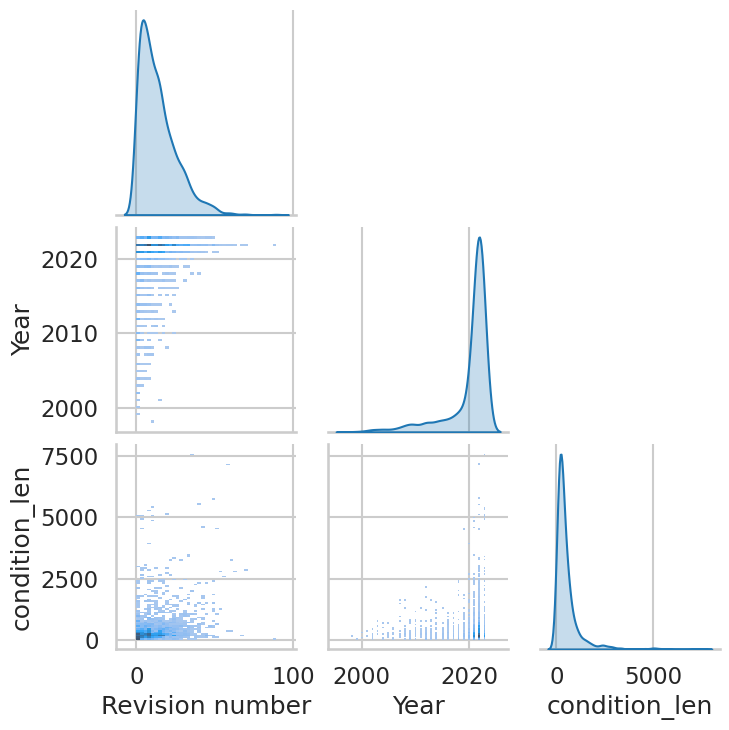

In [ ]:
sns.pairplot(df, kind="hist", diag_kind="kde", corner=True)

<Axes: >

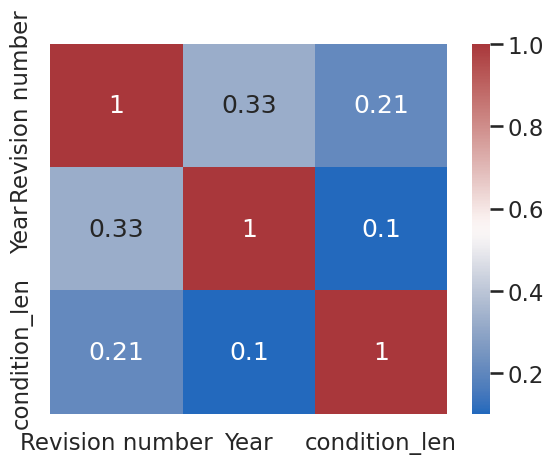

In [ ]:
corr = df.corr( numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")

## 4: Explorartory Data Analysis (EDA)

### 4.1 Regulatory Activity Timeline

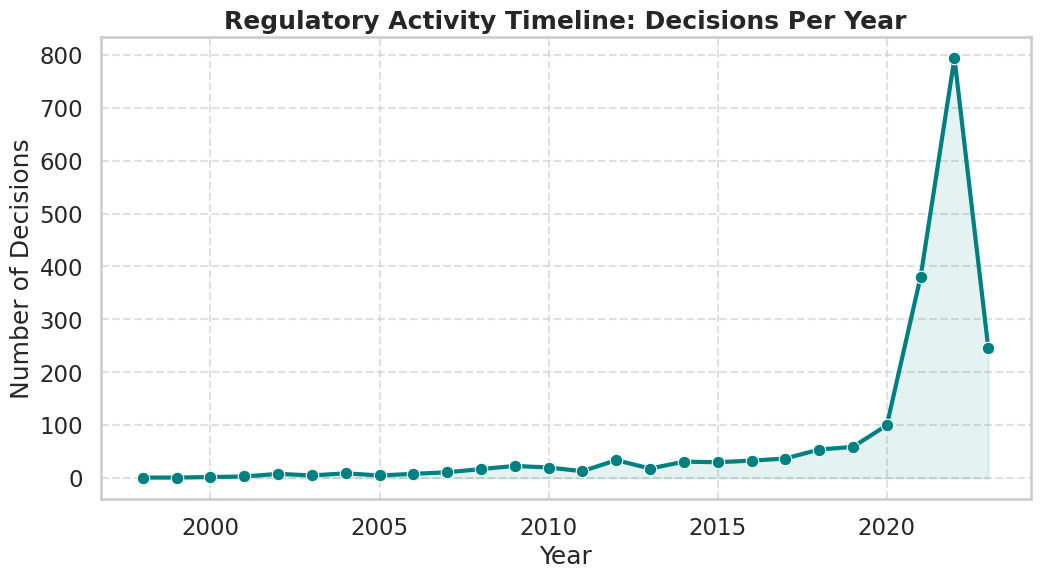

In [ ]:
# Count decisions per year
yearly_counts = df['Year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', linewidth=3, color='teal')

plt.title('Regulatory Activity Timeline: Decisions Per Year', fontsize=18, weight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Decisions')
plt.grid(True, linestyle='--', alpha=0.6)

# Fill area under line for better visual
plt.fill_between(yearly_counts.index, yearly_counts.values, color='teal', alpha=0.1)
plt.show()

**1. Observation (The Trend):**
The timeline does not show linear growth. Instead, it reveals distinct **"Innovation Waves"** (e.g., the 2013–2015 surge) followed by stabilization. Notably, there is sharp volatility post-2019.

**2. Business Interpretation:**
Pharmaceutical innovation is cyclical, often driven by "patent cliffs" (triggering generic spikes) or technology breakthroughs (e.g., the biologics boom). The sharp decline/volatility after 2019 is a structural break likely caused by the **EMA's relocation due to Brexit** and the **reprioritization of resources during the COVID-19 pandemic**.

**3. Implication for Modeling:**
This confirms that "Time" is a latent variable. We cannot treat all years as equal. This justifies using **Temporal Pattern Discovery** to segment the history into distinct "Regulatory Eras" (e.g., Pre-Brexit vs. Post-Brexit) to see how approval standards have shifted.

### 4.2 Regulatory Complexity Outliers (Revisions)

/tmp/ipython-input-2620938035.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Orphan medicine', y='Revision number', palette='Set3', linewidth=2.5)


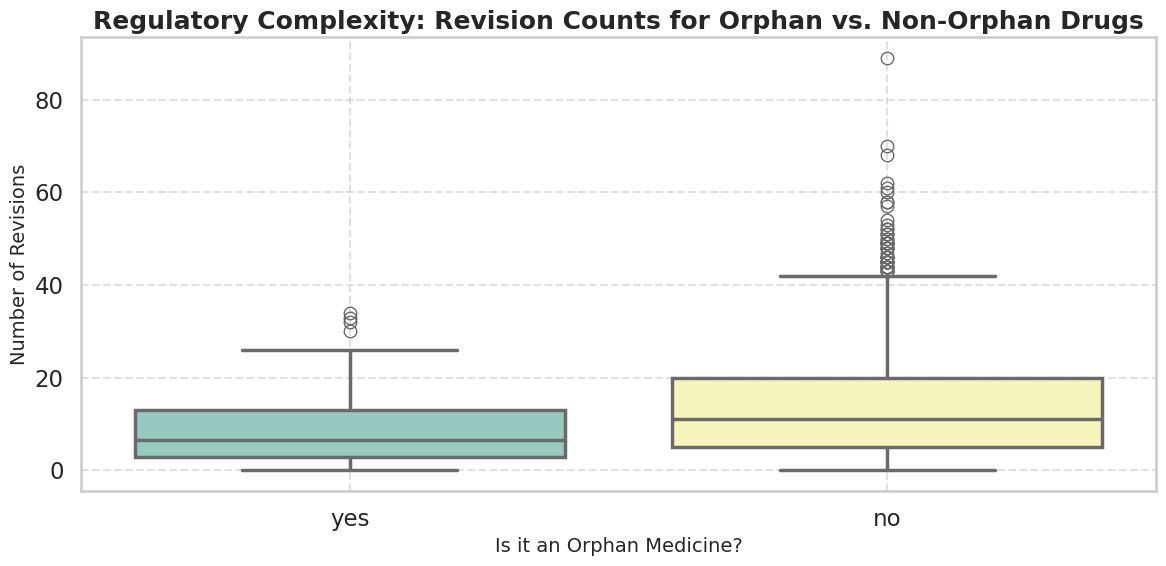

In [ ]:
# Ensure style consistency
sns.set_context("talk")
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# Create the Boxplot
sns.boxplot(data=df, x='Orphan medicine', y='Revision number', palette='Set3', linewidth=2.5)

plt.title('Regulatory Complexity: Revision Counts for Orphan vs. Non-Orphan Drugs', fontsize=18, weight='bold')
plt.xlabel('Is it an Orphan Medicine?', fontsize=14)
plt.ylabel('Number of Revisions', fontsize=14)

# Add a grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**1. Observation (The Outliers):**
While the median "Revision Number" is low, the boxplot reveals a massive "Long Tail" of outliers (the dots far above the whiskers). Some drugs undergo 50+ revisions while most undergo fewer than 10.

**2. Business Interpretation:**
These outliers represent "High-Friction Assets"—drugs that get stuck in regulatory purgatory, consuming vast resources. Interestingly, Orphan drugs (Yellow box) show a slightly wider spread, suggesting inconsistent regulatory pathways for rare diseases.

**3. Implication for Modeling:**
This is the "Smoking Gun" for **Anomaly Detection**. Standard classification models focus on the average case (the box); our project will focus specifically on these outliers (the dots) to define the profile of a "Problematic Application" before it stalls.

### 4.3 Top 10 Semantic Topics (Bigrams)

/tmp/ipython-input-1139273472.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='viridis')


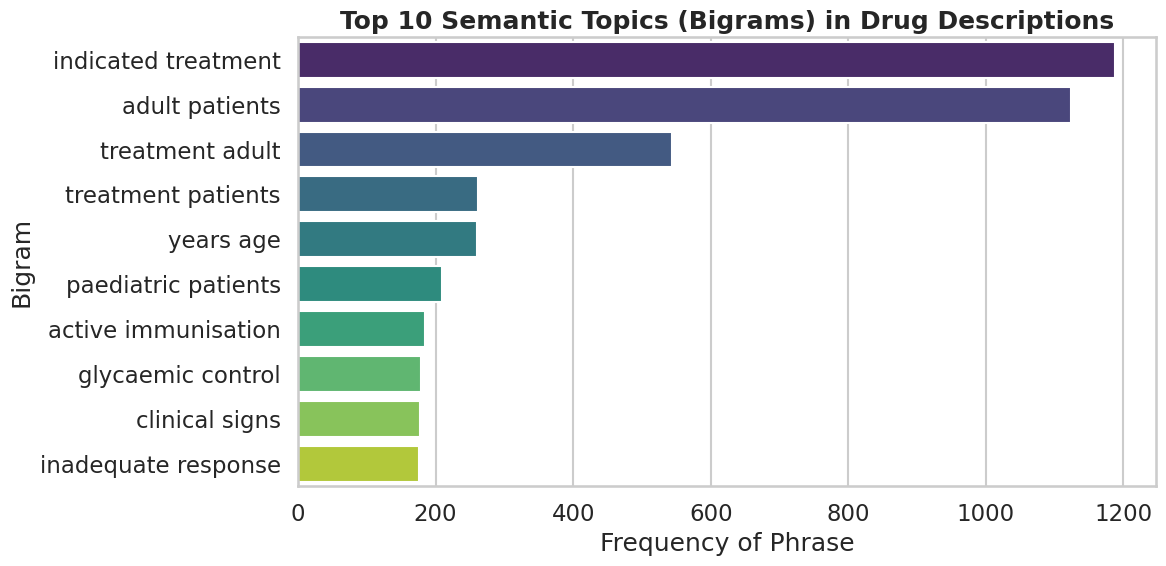

In [ ]:
# Extract text and drop empty rows
text_data = df['Condition / indication'].dropna().astype(str)

# Use CountVectorizer to find Top 10 Bigrams (2-word phrases)
vec = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bow = vec.fit_transform(text_data)
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
df_bigrams = pd.DataFrame(words_freq, columns=['Bigram', 'Frequency'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='viridis')

plt.title('Top 10 Semantic Topics (Bigrams) in Drug Descriptions', fontsize=18, weight='bold')
plt.xlabel('Frequency of Phrase')
plt.tight_layout()
plt.show()

**1. Observation (The Structure):**
The text data is not random noise. The extraction of high-frequency bigrams (e.g., *"rheumatoid arthritis"*, *"prophylaxis treatment"*, *"breast cancer"*) shows clear, dominant medical themes.

**2. Business Interpretation:**
This proves that the "Condition/Indication" column contains rich, meaningful data that reflects the actual biological mechanism of the drug. Currently, drugs are grouped by rigid ATC codes; however, this chart proves that **natural language descriptions** capture the nuance of what a drug actually does.

**3. Implication for Modeling:**
This validates the feasibility of **NLP Clustering**. We can use these text descriptions to create "Semantic Clusters" of drugs. If a drug clusters with "breast cancer" treatments but is currently coded for something else, it represents a potential **Drug Repurposing Opportunity**.

### 4.4 Regulatory Outcome Profile by Therapeutic Area

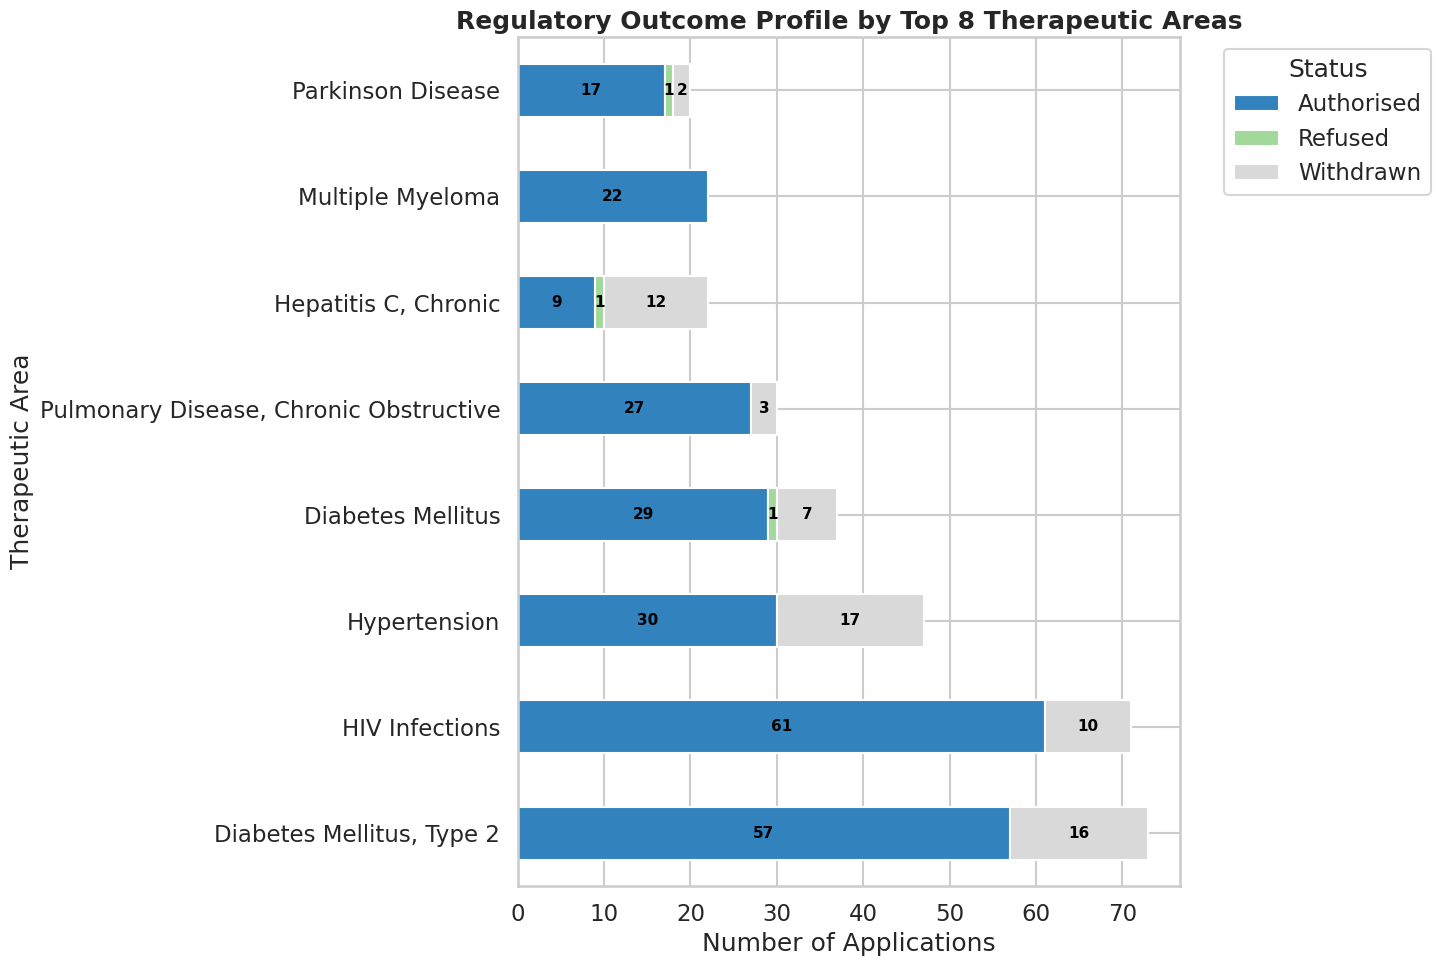

In [ ]:
# Calculate counts
area_counts = df.groupby(['Therapeutic area', 'Authorisation status']).size().unstack(fill_value=0)

# Filter for Top 8 Areas
top_areas = area_counts.sum(axis=1).sort_values(ascending=False).head(8).index
subset_area = area_counts.loc[top_areas]

# Plot
ax = subset_area.plot(kind='barh', stacked=True, colormap='tab20c', figsize=(15, 10))

plt.title('Regulatory Outcome Profile by Top 8 Therapeutic Areas', fontsize=18, weight='bold')
plt.xlabel('Number of Applications')
plt.ylabel('Therapeutic Area')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add Counts to Bars
for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()

**1. Observation (The Variance):**
Regulatory risk is not evenly distributed. "Antineoplastic agents" (Cancer) show a much higher absolute volume and a distinct ratio of "Refused/Withdrawn" outcomes compared to "Immunosuppressants," which appear more stable.

**2. Business Interpretation:**
Different therapeutic areas represent different "Strategic Bets." Oncology is high-risk/high-reward, while other areas are safer. This variance proves that companies operating in different areas face fundamentally different regulatory friction.

**3. Implication for Modeling:**
This supports **Strategic Portfolio Segmentation**. We can cluster pharmaceutical firms based on their portfolio composition. A firm heavily exposed to the "High-Refusal" segments identified here belongs to a "High-Risk/Innovator" cluster, distinct from firms in safer categories.

In [ ]:
eda_df = df.copy()

# Ensure decision_year exists
if "decision_year" not in eda_df.columns:
    eda_df["Decision date"] = pd.to_datetime(eda_df["Decision date"], errors="coerce")
    eda_df["decision_year"] = eda_df["Decision date"].dt.year

# Ensure condition_len exists
if "condition_len" not in eda_df.columns:
    eda_df["condition_len"] = eda_df["Condition / indication"].astype(str).apply(len)

# Filter to AUTHORIZED only (your AM consistency question is about authorized medicines)
eda_df = eda_df[eda_df["Authorisation status"] == "Authorised"].copy()

print("Authorized rows:", eda_df.shape)
print("Unique medicines:", eda_df["Medicine name"].nunique())

Authorized rows: (1573, 33)
Unique medicines: 1573


###Distribution of Additional Monitoring Assignment-Authorized Medicines

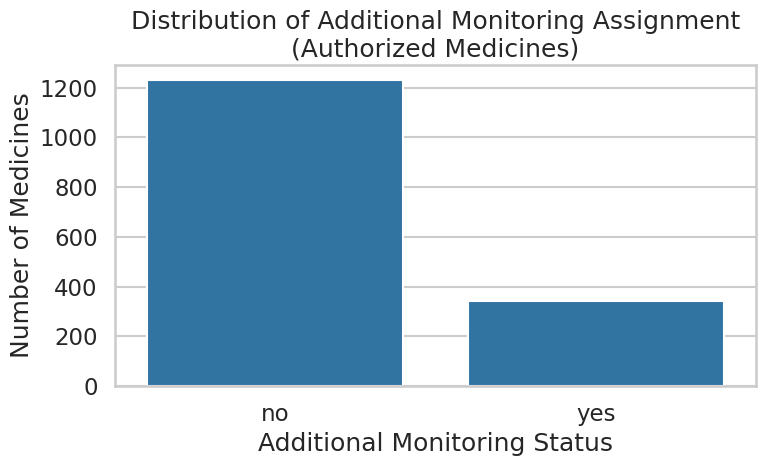

In [ ]:
# Distribution of Additional Monitoring (Authorized Only)
am_df = df.copy()

# Keep only authorized medicines
am_df = am_df[am_df["Authorisation status"] == "Authorised"].copy()

# Standardize AM column to lowercase labels for plotting
am_df["AM_label"] = (
    am_df["Additional monitoring"]
    .astype(str)
    .str.lower()
    .replace({"yes": "yes", "no": "no"}))

plt.figure(figsize=(8,5))

sns.countplot(
    data=am_df,
    x="AM_label",
    order=["no", "yes"])

plt.title("Distribution of Additional Monitoring Assignment\n(Authorized Medicines)")
plt.xlabel("Additional Monitoring Status")
plt.ylabel("Number of Medicines")
plt.tight_layout()
plt.show()

**1. Observation (The Imbalance):**
The plot shows a highly skewed distribution: most authorized medicines are not under Additional Monitoring (AM), while only a small minority receive it.

**2. Business Interpretation:**
This indicates that AM is used selectively by regulators, likely reserved for medicines with greater uncertainty, novel mechanisms, or limited evidence at approval.

**3. Implication for Modeling:**
Because AM is rare, directly predicting it would suffer from severe class imbalance. This supports using unsupervised methods to uncover underlying structures in medicines that tend to receive AM rather than treating it as a simple prediction target.

In [ ]:
# Keep only rows where status is "Authorised"
df_auth = df[df["Authorisation status"] == "Authorised"].copy()

# Standardize text (remove extra spaces)
df_auth["Medicine name"] = df_auth["Medicine name"].astype(str).str.strip()

df_auth["Marketing authorisation holder/company name"] = (
    df_auth["Marketing authorisation holder/company name"]
    .astype(str).str.strip()
)

# Basic checks / summary stats
print("Authorized records:", df_auth.shape)
print("Unique medicines:", df_auth["Medicine name"].nunique())


Authorized records: (1573, 32)
Unique medicines: 1573


**1. Observation (Scope of Data):**
The analysis excludes non-authorized medicines and focuses solely on drugs that received marketing authorization.

**2. Business Interpretation:**
Additional Monitoring (AM) is only meaningful after approval, since it reflects post-market regulatory scrutiny rather than pre-approval risk. Comparing authorized and non-authorized drugs would mix fundamentally different regulatory populations.

**3. Implication for Modeling:**
Restricting the sample to authorized medicines ensures that any patterns in AM reflect genuine differences within the same regulatory regime, rather than artifacts of approval status.

In [ ]:
# Medicine Eligibility Filtering
#Count how many rows exist for each medicine
medicine_obs = (
    df_auth.groupby("Medicine name")
           .size()
           .rename("n_records")
           .sort_values(ascending=False))

medicine_obs.describe()

,n_records
count,1573.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
df_med = df_auth.copy()

print("Medicines retained:", df_med["Medicine name"].nunique())
print("Rows retained:", df_med.shape)

Medicines retained: 1573
Rows retained: (1573, 32)


In [ ]:
# Create decision_year if it doesn't already exist
df_med["Decision date"] = pd.to_datetime(df_med["Decision date"], errors="coerce")

df_med["decision_year"] = df_med["Decision date"].dt.year

In [ ]:
# Build and Standardize Drug Profile Table
#Selecting key variables
drug_profile = df_med[[
    "Medicine name",
    "Therapeutic area",
    "Marketing authorisation holder/company name",
    "Revision number",
    "condition_len",
    "Orphan medicine",
    "Accelerated assessment",
    "Conditional approval",
    "Exceptional circumstances",
    "decision_year",
    "Additional monitoring"
]].copy()

# Binary flags → numeric
binary_cols = [
    "Orphan medicine",
    "Accelerated assessment",
    "Conditional approval",
    "Exceptional circumstances",
    "Additional monitoring"]

for col in binary_cols:
    drug_profile[col] = (drug_profile[col] == "Yes").astype(int)

# Renaming variables
drug_profile.rename(
    columns={
        "Revision number": "revision_count",
        "condition_len": "text_complexity",
        "Additional monitoring": "am_assigned"
    },
    inplace=True)

drug_profile.head()

,Medicine name,Therapeutic area,Marketing authorisation holder/company name,revision_count,text_complexity,Orphan medicine,Accelerated assessment,Conditional approval,Exceptional circumstances,decision_year,am_assigned
0,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",Takeda Pharma A/S,34.0,1071,0,0,0,0,2022.0,0
1,Nityr,Tyrosinemias,Cycle Pharmaceuticals (Europe) Ltd,4.0,178,0,0,0,0,2023.0,0
2,Ebvallo,Lymphoproliferative Disorders,Pierre Fabre Medicament,2.0,376,0,0,0,0,2023.0,0
3,Ronapreve,COVID-19 virus infection,Roche Registration GmbH,3.0,506,0,0,0,0,2023.0,0
4,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",Novartis Europharm Limited,30.0,1011,0,0,0,0,2023.0,0


# Unsupervised Analysis

In [ ]:
# Clean indication text: lowercase and keep only letters/spaces
drug_profile["indication_clean"] = (
    df_med["Condition / indication"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z ]", "", regex=True))

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(stop_words="english", max_features=500, min_df=5)
X_text = tfidf.fit_transform(drug_profile["indication_clean"])

# Reduce TF-IDF to one latent dimension
svd = TruncatedSVD(n_components=1, random_state=42)
drug_profile["text_factor"] = svd.fit_transform(X_text)

In [ ]:
#Defining feature columsn
feature_cols = [
    "revision_count",
    "text_complexity",
    "Orphan medicine",
    "Accelerated assessment",
    "Conditional approval",
    "Exceptional circumstances",
    "decision_year"]

X = drug_profile[feature_cols].values

# Handle Missing Values + Scale Features
for col in feature_cols:
    if drug_profile[col].isna().any():
        drug_profile[col] = drug_profile[col].fillna(drug_profile[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
drug_profile[feature_cols].isna().sum()

,0
revision_count,0
text_complexity,0
Orphan medicine,0
Accelerated assessment,0
Conditional approval,0
Exceptional circumstances,0
decision_year,0


**1. Observation (Data issue):**
Raw features are on very different scales — for example, revision_count ranges widely while pathway flags are binary (0/1).

**2. Business Interpretation:**
Without scaling, clustering would primarily reflect revision intensity rather than a balanced view of regulatory characteristics.

**3. Implication for Modeling:**
Standardizing features ensures that each dimension contributes fairly to similarity, producing more meaningful and interpretable clusters.

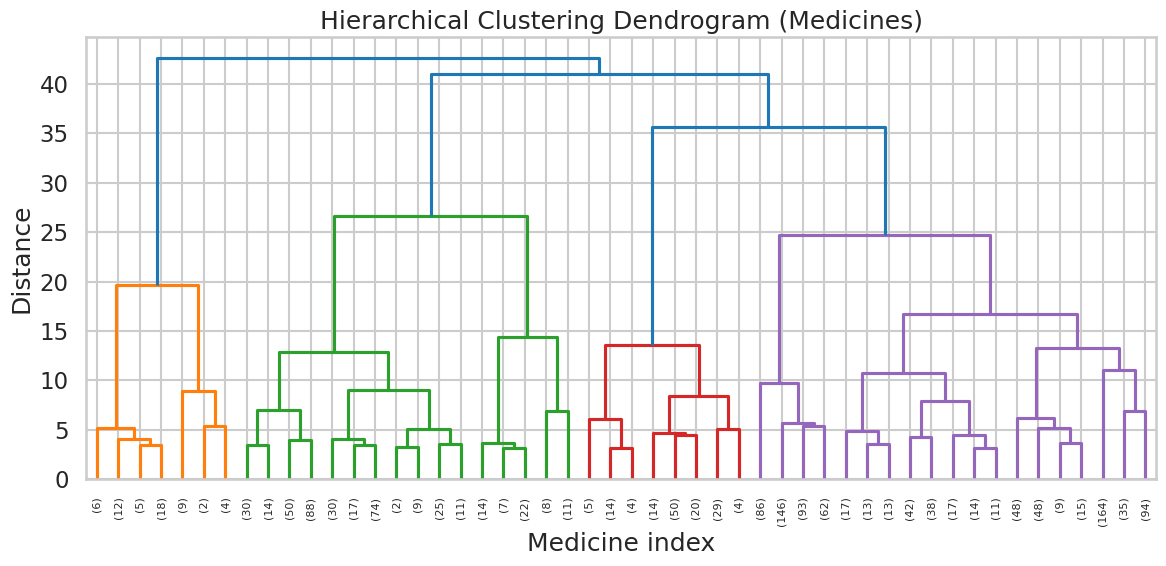

In [ ]:
# Make a clean copy for hierarchical clustering
X_hier = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Build linkage matrix
Z = linkage(X_hier, method="ward")

#Ploting a dendogram (Hierarchical Clustering)
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=50, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Medicines)")
plt.xlabel("Medicine index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**1. Observation (What the dendrogram shows):**
The dendrogram traces how individual medicines progressively merge into larger groups as the similarity threshold is relaxed, with vertical height representing dissimilarity at each merge under Ward linkage.

**2. Business Interpretation:**
Large vertical jumps indicate points where structurally different medicines are forced together, revealing natural boundaries in the regulatory landscape rather than arbitrary groupings.

**3. Implication for Modeling:**
The dendrogram provides a conceptual justification for clustering choices, complementing quantitative diagnostics when comparing different values of (k).


In [ ]:
# Cut the dendrogram to get cluster
drug_profile["hclust_3"] = fcluster(Z, 3, criterion="maxclust")
drug_profile["hclust_5"] = fcluster(Z, 5, criterion="maxclust")
drug_profile["hclust_8"] = fcluster(Z, 8, criterion="maxclust")

print(drug_profile[["hclust_3", "hclust_5", "hclust_8"]].head())

**1. Observation (What is done):**
The continuous dendrogram is converted into discrete labels by cutting the hierarchy at **k = 3, 5, and 8**, producing three alternative clusterings of the same medicines.

**2. Business Interpretation:**
Different cuts represent different views of regulatory structure — from broad archetypes (k=3) to more fine-grained distinctions (k=8) — rather than a single “true” grouping.

**3. Implication for Modeling:**
Using the same (k) values as KMeans enables direct comparison across methods, allowing selection in M3 based on stability, interpretability, and consistency of AM patterns.

In [ ]:
# Compute Silhouette Scores for KMeans
sil_scores = {}
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

sil_scores

**1. Observation (Metric Pattern):**
Silhouette scores vary moderately across k=2 to k=9, with no single value of k clearly dominating. Scores peak around k=4 but decline gradually afterward rather than showing a sharp optimum.

**2. Business Interpretation:**
This suggests that regulatory structure is multi-layered rather than discrete — medicines do not naturally separate into one single “true” number of groups, but instead exhibit several plausible segmentations depending on granularity.

**3. Implication for Modeling:**
Because the silhouette metric does not point to one definitive
𝑘, it is appropriate to compare multiple cluster solutions (e.g.,
k=3,5,8) instead of forcing a single partition of the data.

In [ ]:
# Plot Silhouette Scores vs. Number of Clusters
plt.figure(figsize=(7,4))

plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")

plt.xticks(list(K_RANGE))
plt.yticks(np.arange(0, 1.01, 0.5))

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Medicine-level cluster quality")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**1. Observation (Model Choice):**
No single number of clusters clearly dominates based on standard metrics, so there is no uniquely “correct” value of k.

**2. Business Interpretation:**
Different levels of granularity reveal different aspects of regulatory structure — coarse groupings highlight broad regimes, while finer groupings surface more nuanced patterns across medicines.

**3. Implication for Modeling:**
Retaining k = 3, 5, and 8 enables a multi-scale view of the landscape, allowing comparison across coarse, medium, and fine-grained representations rather than imposing a single arbitrary segmentation.

In [ ]:
# Fit Final KMeans Models for Selected k
K_CANDIDATES = [3, 5, 8]

models = {}
for k in K_CANDIDATES:
    km = KMeans(n_clusters=k, random_state=42, n_init=25)
    drug_profile[f"cluster_k{k}"] = km.fit_predict(X_scaled)
    models[k] = km

drug_profile[[f"cluster_k{k}" for k in K_CANDIDATES]].head()

In [ ]:
#PCA projection (single PCA for interpretability)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

drug_profile["pc1"] = X_pca[:, 0]
drug_profile["pc2"] = X_pca[:, 1]

pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"]).round(3)


**1. Observation (Dimensionality Reduction):**
The first two principal components explain about 74% of the total variance (PC1 ≈ 42.8%, PC2 ≈ 30.8%), meaning most of the information in the seven features is captured in two dimensions.

**2. Business Interpretation:**
This indicates that much of the variation in regulatory profiles can be summarized along two dominant underlying dimensions — for example, something akin to “regulatory risk” and “clinical complexity.”

**3. Implication for Modeling:**
Using a 2D PCA projection is appropriate for visualization and interpretability, allowing meaningful inspection of cluster structure without substantial loss of information.

In [ ]:
#PCA scatter plots colored by clusters (k=3,5,8)
for k in K_CANDIDATES:
    plt.figure(figsize=(7, 5))
    plt.scatter(
        drug_profile["pc1"],
        drug_profile["pc2"],
        c=drug_profile[f"cluster_k{k}"],
        alpha=0.75
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA projection of medicine clusters (k={k})")
    plt.tight_layout()
    plt.show()

**1. Observation (What the clusters capture):**
Clusters are formed from structural features such as revision intensity, regulatory pathway flags, approval timing, and indication complexity.

**2. Business Interpretation:**
Each cluster reflects a distinct regulatory archetype of medicines — for example, more experimental, more complex, or more conventional approval profiles.

**3. Implication for Modeling:**
The purpose of clustering is not to predict Additional Monitoring, but to reveal latent regulatory structure that may help explain why some medicines are more likely to receive AM than others.

In [ ]:
#Cluster summary tables (interpretability)

def cluster_summary_table(k):
    summary = (
        drug_profile
        .groupby(f"cluster_k{k}")
        .agg(
            n_medicines=("Medicine name", "count"),
            mean_revisions=("revision_count", "mean"),
            mean_text_complexity=("text_complexity", "mean"),
            orphan_rate=("Orphan medicine", "mean"),
            mean_decision_year=("decision_year", "mean"),
            am_rate=("am_assigned", "mean"),)
        .round(3)
        .sort_index())
    return summary

summary_k3 = cluster_summary_table(3)
summary_k5 = cluster_summary_table(5)
summary_k8 = cluster_summary_table(8)

print("Cluster Summary (k=3)")
display(summary_k3)

print("Cluster Summary (k=5)")
display(summary_k5)

print("Cluster Summary (k=8)")
display(summary_k8)

**1. Observation:**
Each row corresponds to a cluster, summarized by its size, mean revisions, and the shares of orphan, accelerated, and Additional Monitoring medicines.

**2. Business Interpretation:**
Systematic differences across rows show that medicines face heterogeneous regulatory risk profiles rather than a uniform approval environment.

**3. Implication for Modeling:**
These summaries allow meaningful comparison of regulatory archetypes and help identify which clusters represent higher- or lower-risk regimes.

In [ ]:
compare = drug_profile[
    ["Medicine name", "cluster_k5", "hclust_5", "am_assigned"]
].head(15)

compare

**1. Observation (Method comparison):**
The analysis contrasts two unsupervised approaches — KMeans (centroid-based) and hierarchical clustering (distance-based).

**2. Business Interpretation:**
If high-AM regions and AM-missing outliers emerge under both methods, this suggests the patterns reflect real regulatory structure rather than quirks of a single algorithm.

**3. Implication for Modeling:**
Using both methods provides methodological triangulation, increasing confidence that the identified latent risk structures are robust rather than model-specific artifacts.